# Quant Backtest — Analysis
Equity curves, drawdowns, rolling metrics, and portfolio weights.

In [1]:
%matplotlib inline

import sys
sys.path.insert(0, '../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

from data import load, get_close
from features import build_feature_matrix
from strategy import momentum_strategy, composite_strategy, risk_managed_strategy
from backtest import run, BacktestConfig, benchmark_returns, benchmark_equity
from metrics import summary, compare, drawdown_series, drawdown_table

sns.set_theme(style='darkgrid', palette='tab10')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi'] = 110

COLORS = {'Momentum': '#2196F3', 'Composite': '#FF9800', 'Risk-Managed': '#4CAF50', 'SPY': '#9E9E9E'}

In [2]:
close = get_close(load())
fm    = build_feature_matrix(close)
cfg   = BacktestConfig(commission=0.001, slippage=0.0005)

w1 = momentum_strategy(fm, top_n=10, signal='mom_6m')
w2 = composite_strategy(fm, top_n=10)
w3 = risk_managed_strategy(fm, close, top_n=10, target_vol=0.15)

r1 = run(w1, close, cfg)
r2 = run(w2, close, cfg)
r3 = run(w3, close, cfg)

bm_eq  = benchmark_equity(close).reindex(r1['equity'].index)
bm_ret = bm_eq.pct_change().fillna(0)

def norm(s): return s / s.iloc[0] * 100

eq = pd.DataFrame({
    'Momentum':     norm(r1['equity']),
    'Composite':    norm(r2['equity']),
    'Risk-Managed': norm(r3['equity']),
    'SPY':          norm(bm_eq),
})
print('Date range:', eq.index[0].date(), '->', eq.index[-1].date())

2026-04-24 19:16:33,376 INFO Loaded universe.parquet  shape: (2842, 145)


build_feature_matrix: dropped 7317 rows with NaN (8.9%) — warm-up period
Date range: 2016-01-04 -> 2026-04-22


## 1. Equity Curves

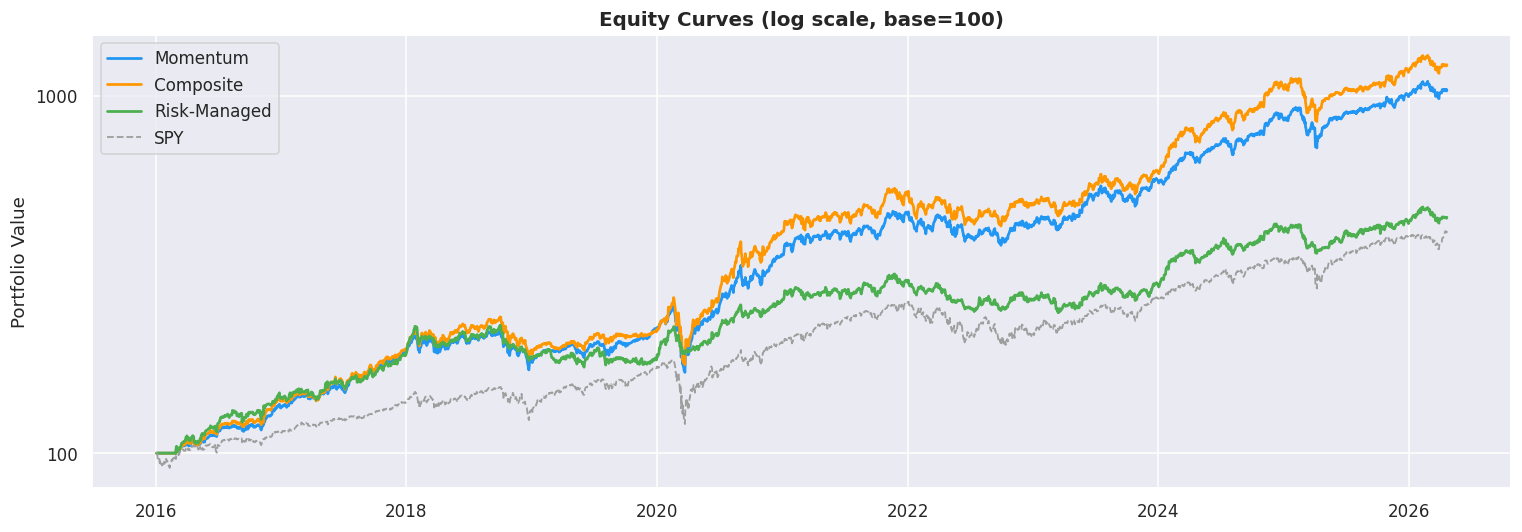

In [3]:
fig, ax = plt.subplots()
for col in eq.columns:
    ax.plot(eq.index, eq[col], label=col,
            color=COLORS[col],
            linestyle='--' if col == 'SPY' else '-',
            linewidth=1.2 if col == 'SPY' else 1.8)
ax.set_yscale('log')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:.0f}'))
ax.set_title('Equity Curves (log scale, base=100)', fontsize=13, fontweight='bold')
ax.set_ylabel('Portfolio Value')
ax.legend()
plt.tight_layout()
plt.show()

## 2. Drawdown Comparison

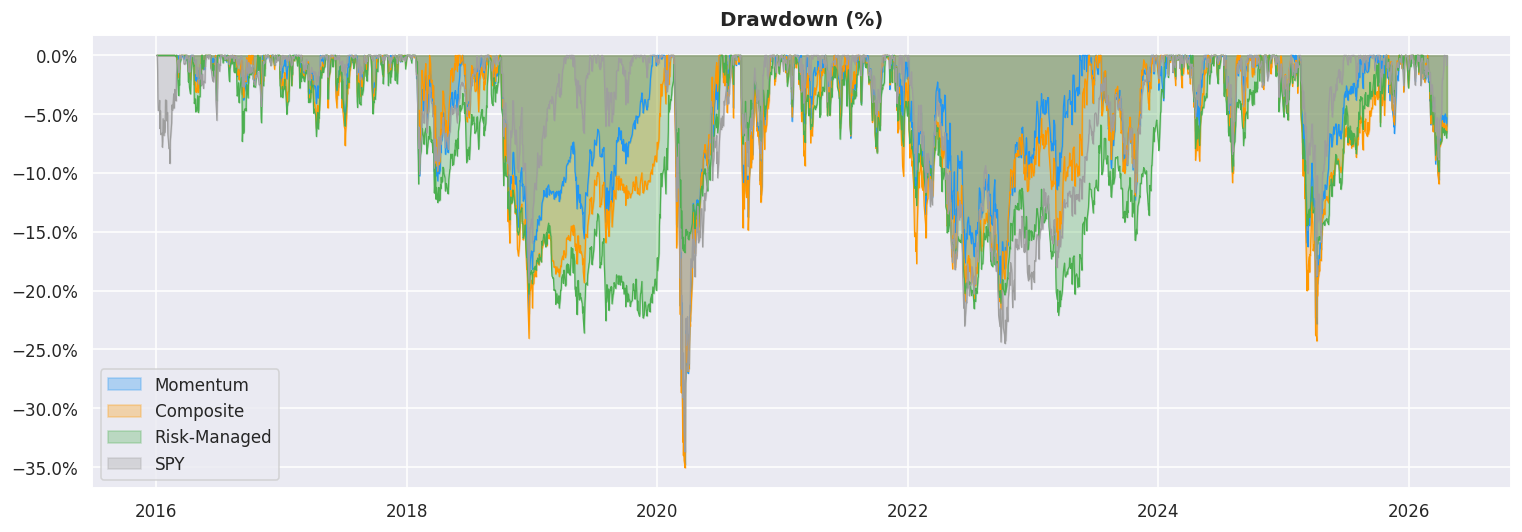

In [4]:
dd = pd.DataFrame({
    'Momentum':     drawdown_series(r1['equity']),
    'Composite':    drawdown_series(r2['equity']),
    'Risk-Managed': drawdown_series(r3['equity']),
    'SPY':          drawdown_series(bm_eq),
})
fig, ax = plt.subplots()
for col in dd.columns:
    ax.fill_between(dd.index, dd[col] * 100, 0, alpha=0.3, color=COLORS[col], label=col)
    ax.plot(dd.index, dd[col] * 100, color=COLORS[col], linewidth=0.8)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_title('Drawdown (%)', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

## 3. Summary Table

In [5]:
spy_ret = benchmark_returns(close, 'SPY').reindex(r1['returns'].index)
report = compare([
    summary(r1['equity'], r1['returns'], spy_ret, label='Momentum'),
    summary(r2['equity'], r2['returns'], spy_ret, label='Composite'),
    summary(r3['equity'], r3['returns'], spy_ret, label='Risk-Managed'),
    summary(bm_eq, bm_ret, label='SPY'),
])
report

,Momentum,Composite,Risk-Managed,SPY
Total Return,939.07%,1120.94%,356.79%,317.94%
CAGR,25.53%,27.51%,15.90%,14.90%
Volatility (ann),20.27%,22.44%,16.96%,17.91%
Sharpe Ratio,1.03,1.02,0.73,0.65
Sortino Ratio,1.28,1.29,0.98,0.78
Calmar Ratio,0.73,0.78,0.67,0.44
Max Drawdown,-34.79%,-35.06%,-23.60%,-33.72%
Win Rate,55.37%,55.06%,54.40%,55.41%
Avg Win / Loss,0.98,0.98,0.96,0.95
VaR 95% (daily),1.91%,2.10%,1.70%,1.68%


## 4. Rolling Sharpe (252-day)

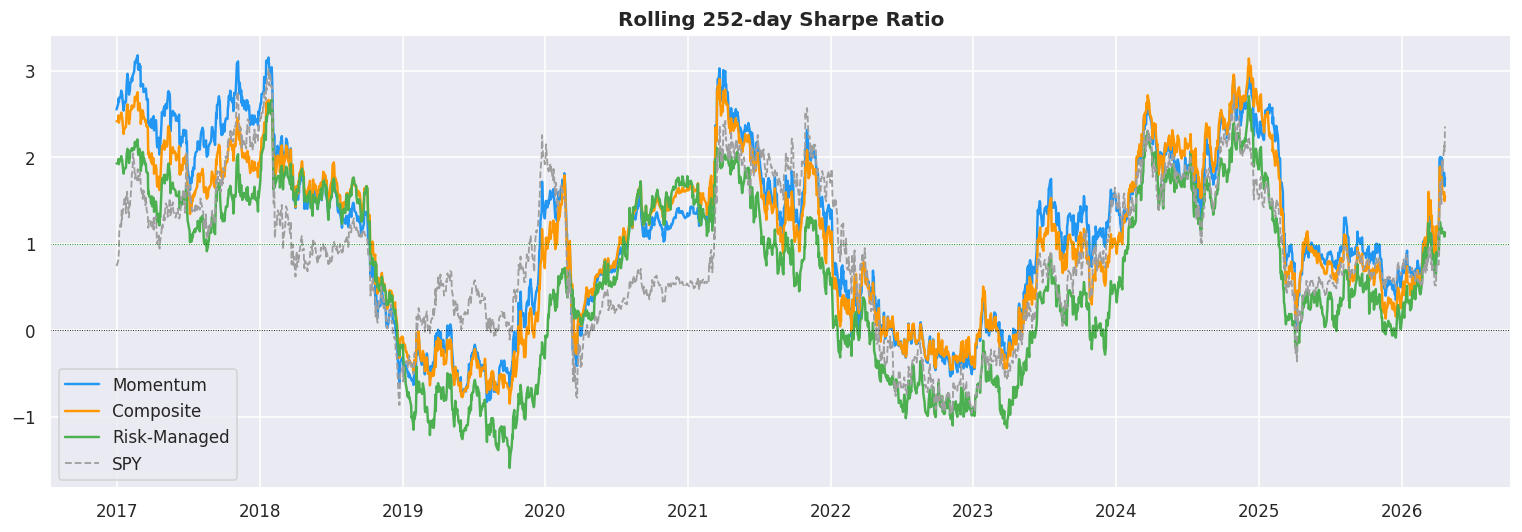

In [6]:
def rolling_sharpe(returns, window=252, rf=0.04):
    rf_d = (1 + rf) ** (1/252) - 1
    exc  = returns - rf_d
    return (exc.rolling(window).mean() / exc.rolling(window).std()) * np.sqrt(252)

fig, ax = plt.subplots()
for label, ret in [('Momentum', r1['returns']), ('Composite', r2['returns']),
                   ('Risk-Managed', r3['returns']), ('SPY', bm_ret)]:
    ax.plot(rolling_sharpe(ret), label=label, color=COLORS[label],
            linewidth=1.2 if label == 'SPY' else 1.6,
            linestyle='--' if label == 'SPY' else '-')
ax.axhline(0, color='black', linewidth=0.6, linestyle=':')
ax.axhline(1, color='green', linewidth=0.6, linestyle=':')
ax.set_title('Rolling 252-day Sharpe Ratio', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

## 5. Monthly Returns Heatmap (Risk-Managed)

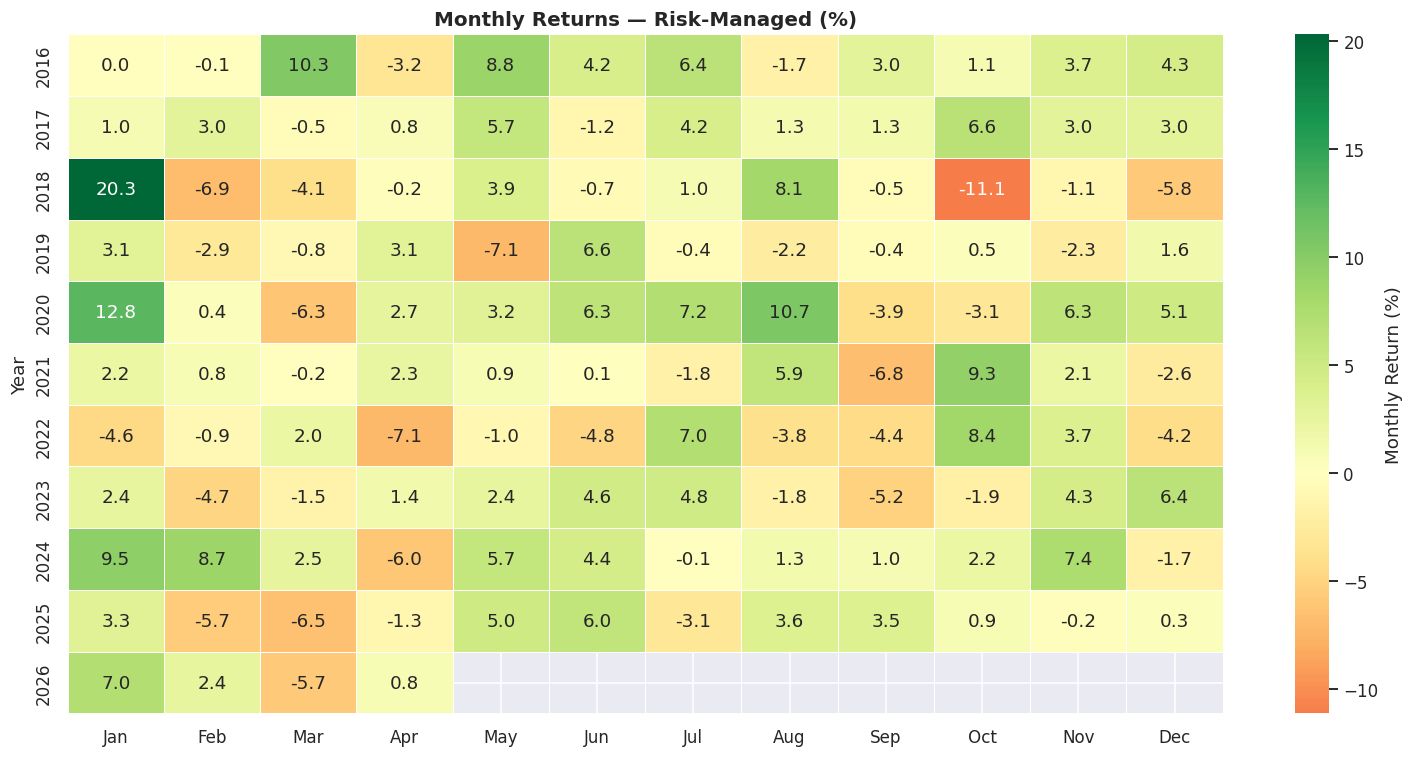

In [7]:
monthly = (1 + r3['returns']).resample('ME').prod() - 1
table   = monthly.groupby([monthly.index.year, monthly.index.month]).first().unstack()
table.columns = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax = plt.subplots(figsize=(14, len(table) * 0.55 + 1))
sns.heatmap(table * 100, annot=True, fmt='.1f', center=0,
            cmap='RdYlGn', linewidths=0.4, ax=ax,
            cbar_kws={'label': 'Monthly Return (%)'})
ax.set_title('Monthly Returns — Risk-Managed (%)', fontsize=13, fontweight='bold')
ax.set_ylabel('Year')
plt.tight_layout()
plt.show()

## 6. Turnover & Costs

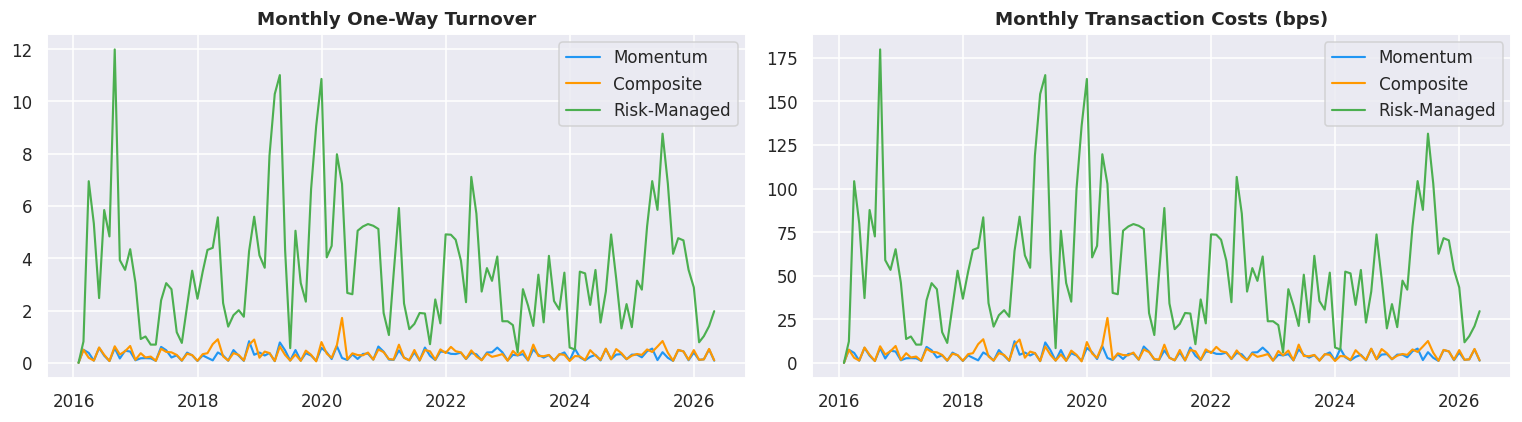

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for label, res in [('Momentum', r1), ('Composite', r2), ('Risk-Managed', r3)]:
    axes[0].plot(res['turnover'].resample('ME').sum(), label=label, color=COLORS[label], linewidth=1.4)
    axes[1].plot(res['costs'].resample('ME').sum() * 1e4, label=label, color=COLORS[label], linewidth=1.4)
axes[0].set_title('Monthly One-Way Turnover', fontweight='bold')
axes[0].legend()
axes[1].set_title('Monthly Transaction Costs (bps)', fontweight='bold')
axes[1].legend()
plt.tight_layout()
plt.show()

## 7. Drawdown Periods Table

In [9]:
print('=== Composite ===')
display(drawdown_table(r2['equity'], top_n=5))
print('\n=== Risk-Managed ===')
display(drawdown_table(r3['equity'], top_n=5))

=== Composite ===


,start,trough,recovery,drawdown,duration_days
0,2020-02-20,2020-03-23,2020-06-30,-35.06%,131
1,2025-01-24,2025-04-08,2025-10-28,-24.28%,277
2,2018-10-02,2018-12-24,2020-01-30,-24.06%,485
3,2021-11-26,2022-09-30,2023-06-13,-21.56%,564
4,2020-09-02,2020-09-23,2020-12-01,-14.86%,90



=== Risk-Managed ===


,start,trough,recovery,drawdown,duration_days
0,2018-10-02,2019-06-03,2020-07-06,-23.60%,643
1,2021-11-26,2023-03-17,2024-01-24,-22.10%,789
2,2024-12-12,2025-04-08,2025-10-28,-17.28%,320
3,2018-01-29,2018-04-02,2018-10-01,-12.51%,245
4,2024-07-11,2024-08-05,2024-10-24,-9.91%,105


## 8. Current Portfolio Weights (Risk-Managed)

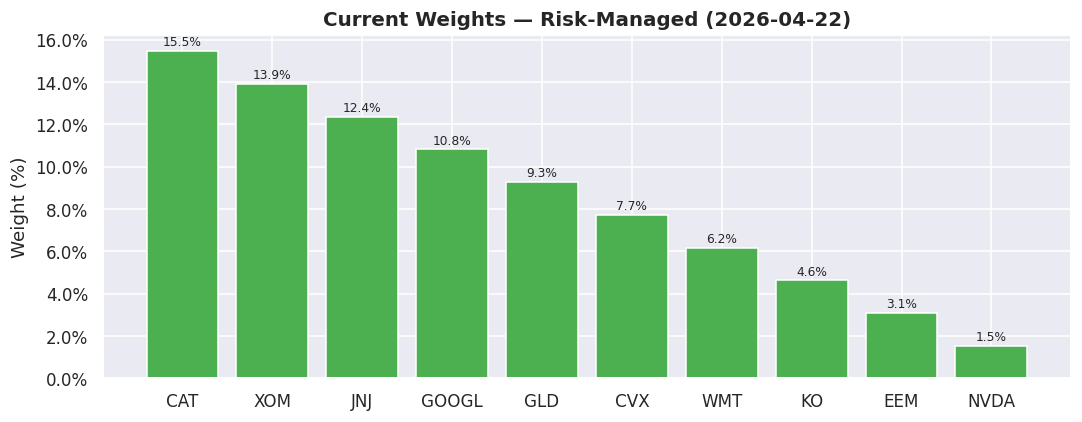

In [10]:
last_w = r3['weights_act'].iloc[-1].sort_values(ascending=False)
last_w = last_w[last_w > 0.001]

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(last_w.index, last_w * 100, color='#4CAF50', edgecolor='white')
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=8)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_title(f'Current Weights — Risk-Managed ({r3["weights_act"].index[-1].date()})',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Weight (%)')
plt.tight_layout()
plt.show()

## 9. Walk-Forward Validation

In [11]:
import sys
sys.path.insert(0, '../src')

from walkforward import run_walkforward, compare_is_vs_oos, WalkForwardConfig

wf_cfg = WalkForwardConfig(train_years=3, test_months=6)

def strat_momentum(fm_slice, close_slice):
    return momentum_strategy(fm_slice, top_n=10, signal='mom_6m')

def strat_composite(fm_slice, close_slice):
    return composite_strategy(fm_slice, top_n=10)

def strat_risk(fm_slice, close_slice):
    return risk_managed_strategy(fm_slice, close_slice, top_n=10)

print("=== Walk-forward: Momentum ===")
wf_mom = run_walkforward(strat_momentum, close, fm, wf_cfg, cfg, label='Momentum')

print("\n=== Walk-forward: Composite ===")
wf_cmp = run_walkforward(strat_composite, close, fm, wf_cfg, cfg, label='Composite')

print("\n=== Walk-forward: Risk-Managed ===")
wf_rm  = run_walkforward(strat_risk,      close, fm, wf_cfg, cfg, label='Risk-Managed')

=== Walk-forward: Momentum ===
  Fold  1 | train 2016-01-04→2019-01-04 | OOS 2019-01-05→2019-07-04 | CAGR=+24.8%  Sharpe=1.76  MDD=-8.9%
  Fold  2 | train 2016-07-04→2019-07-04 | OOS 2019-07-05→2020-01-04 | CAGR=+21.1%  Sharpe=1.14  MDD=-8.5%
  Fold  3 | train 2017-01-04→2020-01-04 | OOS 2020-01-05→2020-07-04 | CAGR=+35.2%  Sharpe=0.78  MDD=-34.8%
  Fold  4 | train 2017-07-04→2020-07-04 | OOS 2020-07-05→2021-01-04 | CAGR=+79.2%  Sharpe=2.18  MDD=-13.8%
  Fold  5 | train 2018-01-04→2021-01-04 | OOS 2021-01-05→2021-07-04 | CAGR=+33.0%  Sharpe=1.38  MDD=-5.8%
  Fold  6 | train 2018-07-04→2021-07-04 | OOS 2021-07-05→2022-01-04 | CAGR=+29.1%  Sharpe=1.27  MDD=-8.1%
  Fold  7 | train 2019-01-04→2022-01-04 | OOS 2022-01-05→2022-07-04 | CAGR=-21.5%  Sharpe=-1.05  MDD=-15.7%
  Fold  8 | train 2019-07-04→2022-07-04 | OOS 2022-07-05→2023-01-04 | CAGR=+19.6%  Sharpe=0.85  MDD=-10.6%
  Fold  9 | train 2020-01-04→2023-01-04 | OOS 2023-01-05→2023-07-04 | CAGR=+49.2%  Sharpe=2.13  MDD=-8.4%
  Fold 10 

### 9a. OOS Equity Curve vs In-Sample

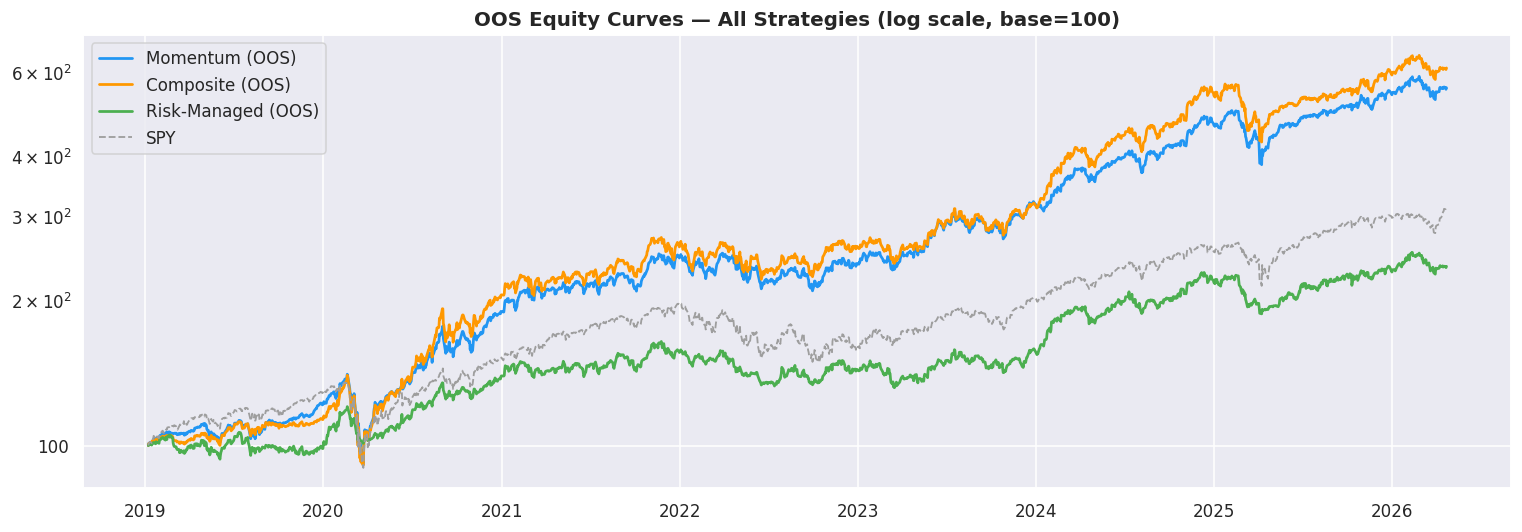

In [12]:
# OOS equity curves — all three strategies vs SPY
oos_start = wf_mom['oos_equity'].index[0]
bm_eq_oos = bm_eq.loc[oos_start:]

fig, ax = plt.subplots()
for wf_x, label, color in [
    (wf_mom, 'Momentum',     COLORS['Momentum']),
    (wf_cmp, 'Composite',    COLORS['Composite']),
    (wf_rm,  'Risk-Managed', COLORS['Risk-Managed']),
]:
    ax.plot(norm(wf_x['oos_equity']), label=f'{label} (OOS)', color=color, linewidth=1.8)
ax.plot(norm(bm_eq_oos), label='SPY', color=COLORS['SPY'], linewidth=1.2, linestyle='--')
ax.set_yscale('log')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:.0f}'))
ax.set_title('OOS Equity Curves — All Strategies (log scale, base=100)', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

### 9b. Per-Fold Sharpe & CAGR

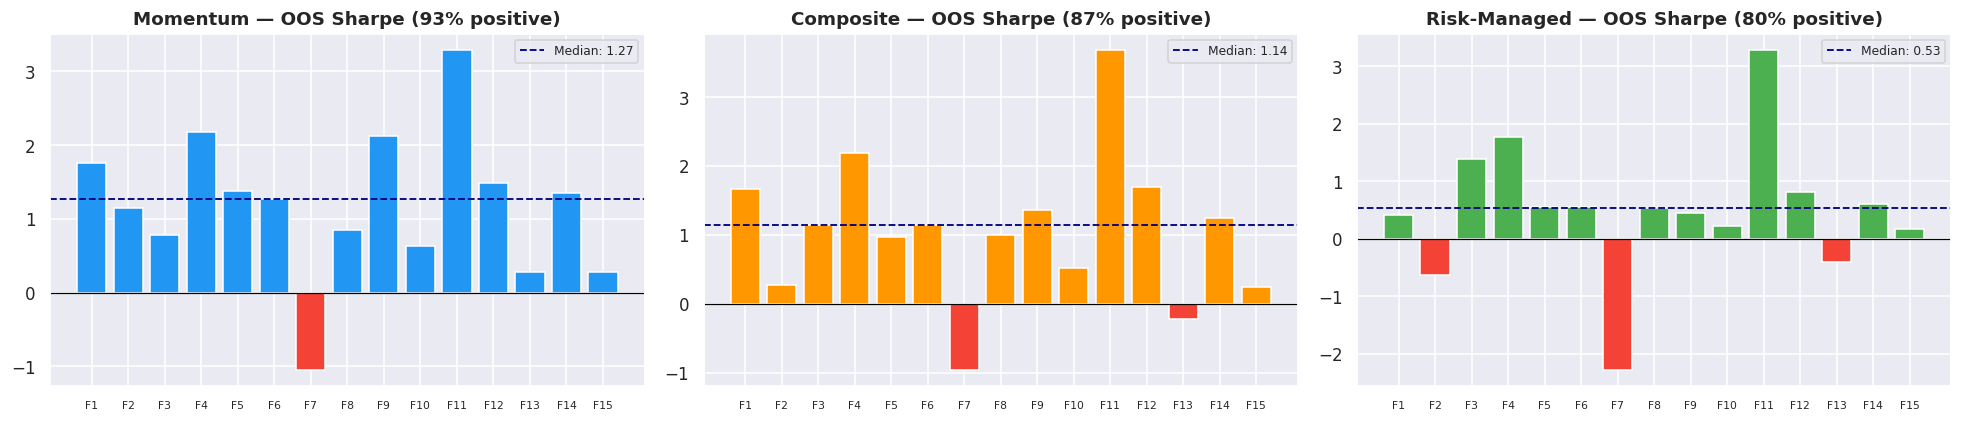

,Median Sharpe,Median CAGR,% Pos Sharpe,Median MDD,Worst Fold Sharpe,Best Fold Sharpe
Strategy,,,,,,
Momentum,1.27,26.2%,93%,-10.0%,-1.05,3.29
Composite,1.14,26.0%,87%,-10.8%,-0.97,3.69
Risk-Managed,0.53,12.2%,80%,-9.9%,-2.29,3.29


In [13]:
# Per-fold Sharpe — all three strategies side by side
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for ax, (wf_x, label, color) in zip(axes, [
    (wf_mom, 'Momentum',     COLORS['Momentum']),
    (wf_cmp, 'Composite',    COLORS['Composite']),
    (wf_rm,  'Risk-Managed', COLORS['Risk-Managed']),
]):
    fd = wf_x['fold_metrics'].reset_index()
    x  = range(len(fd))
    bar_colors = [color if v >= 0 else '#F44336' for v in fd['sharpe']]
    ax.bar(x, fd['sharpe'], color=bar_colors, edgecolor='white')
    ax.axhline(0, color='black', linewidth=0.8)
    med = wf_x['fold_metrics']['sharpe'].median()
    ax.axhline(med, color='navy', linewidth=1.2, linestyle='--', label=f'Median: {med:.2f}')
    ax.set_xticks(list(x))
    ax.set_xticklabels([f"F{i}" for i in fd['fold']], fontsize=7)
    pct = (wf_x['fold_metrics']['sharpe'] > 0).mean()
    ax.set_title(f'{label} — OOS Sharpe ({pct:.0%} positive)', fontweight='bold')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# Riepilogo statistiche OOS per strategia
rows = []
for wf_x, label in [(wf_mom, 'Momentum'), (wf_cmp, 'Composite'), (wf_rm, 'Risk-Managed')]:
    fm_s = wf_x['fold_metrics']
    rows.append({
        'Strategy':          label,
        'Median Sharpe':     round(fm_s['sharpe'].median(), 2),
        'Median CAGR':       f"{fm_s['cagr'].median():.1%}",
        '% Pos Sharpe':      f"{(fm_s['sharpe'] > 0).mean():.0%}",
        'Median MDD':        f"{fm_s['max_dd'].median():.1%}",
        'Worst Fold Sharpe': round(fm_s['sharpe'].min(), 2),
        'Best Fold Sharpe':  round(fm_s['sharpe'].max(), 2),
    })
display(pd.DataFrame(rows).set_index('Strategy'))

### 9c. IS vs OOS Summary Table

In [14]:
# IS vs OOS — tutte le strategie + SPY
from metrics import summary as ms

bm_ret_oos = benchmark_returns(close).reindex(wf_rm['oos_returns'].index).fillna(0)
bm_eq_oos2 = (1 + bm_ret_oos).cumprod()

cols = []
for wf_x, r_is, label in [
    (wf_mom, r1, 'Momentum'),
    (wf_cmp, r2, 'Composite'),
    (wf_rm,  r3, 'Risk-Managed'),
]:
    cols.append(ms(r_is['equity'],       r_is['returns'],                    label=f'{label} IS'))
    cols.append(ms(wf_x['oos_equity'],   wf_x['oos_returns'], bm_ret_oos,    label=f'{label} OOS'))

cols.append(ms(bm_eq_oos2, bm_ret_oos, label='SPY (OOS period)'))
compare(cols)

,Momentum IS,Momentum OOS,Composite IS,Composite OOS,Risk-Managed IS,Risk-Managed OOS,SPY (OOS period)
Total Return,939.07%,456.55%,1120.94%,511.94%,356.79%,136.20%,211.25%
CAGR,25.53%,26.56%,27.51%,28.22%,15.90%,12.52%,16.86%
Volatility (ann),20.27%,21.77%,22.44%,23.96%,16.96%,16.76%,19.54%
Sharpe Ratio,1.03,1.01,1.02,1.00,0.73,0.55,0.70
Sortino Ratio,1.28,1.27,1.29,1.28,0.98,0.79,0.86
Calmar Ratio,0.73,0.76,0.78,0.80,0.67,0.63,0.50
Max Drawdown,-34.79%,-34.79%,-35.06%,-35.06%,-23.60%,-19.89%,-33.72%
Win Rate,55.37%,54.88%,55.06%,54.72%,54.40%,53.57%,55.65%
Avg Win / Loss,0.98,1.00,0.98,1.00,0.96,0.97,0.95
VaR 95% (daily),1.91%,1.97%,2.10%,2.15%,1.70%,1.71%,1.75%


### 9d. Fold 11 Deep-Dive (Sharpe 3.29 — anomaly investigation)

Fold 11 OOS: 2024-01-05 → 2024-07-04  (124 giorni)
SPY:      +18.6%
Strategy: +31.5%


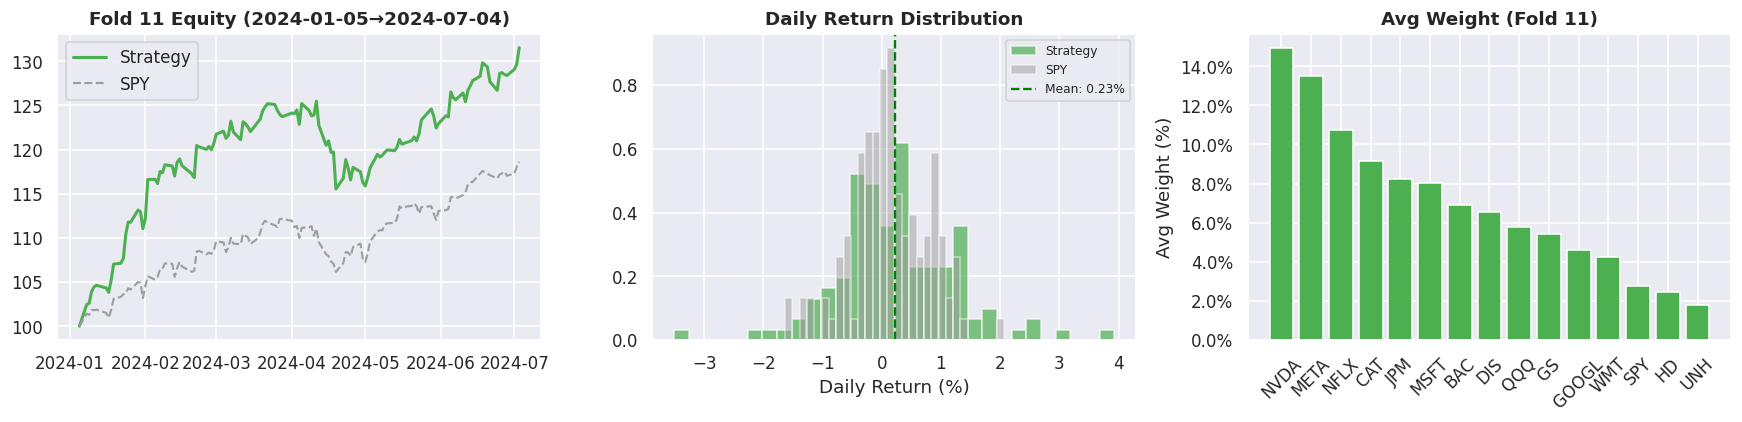

In [15]:
FOLD_N = 11
fold   = next(f for f in wf_rm['folds'] if f['fold'] == FOLD_N)
f11_ret = fold['result']['returns']
f11_eq  = fold['result']['equity']
f11_w   = fold['result']['weights_act']
t_start, t_end = fold['test_start'], fold['test_end']

spy_f11 = close['SPY'].loc[t_start:t_end].pct_change().fillna(0)
spy_eq  = (1 + spy_f11).cumprod() * f11_eq.iloc[0]

print(f"Fold 11 OOS: {t_start.date()} → {t_end.date()}  ({len(f11_ret)} giorni)")
print(f"SPY:      {spy_f11.add(1).prod()-1:+.1%}")
print(f"Strategy: {f11_eq.iloc[-1]/f11_eq.iloc[0]-1:+.1%}")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

norm11 = lambda s: s / s.iloc[0] * 100
axes[0].plot(norm11(f11_eq), label='Strategy', color='#4CAF50', linewidth=2)
axes[0].plot(norm11(spy_eq), label='SPY',      color='#9E9E9E', linewidth=1.4, linestyle='--')
axes[0].set_title(f'Fold 11 Equity ({t_start.date()}→{t_end.date()})', fontweight='bold')
axes[0].legend()

axes[1].hist(f11_ret * 100, bins=30, color='#4CAF50', alpha=0.7, label='Strategy', density=True)
axes[1].hist(spy_f11 * 100, bins=30, color='#9E9E9E', alpha=0.5, label='SPY',      density=True)
axes[1].axvline(f11_ret.mean()*100, color='green', linewidth=1.5, linestyle='--',
                label=f'Mean: {f11_ret.mean()*100:.2f}%')
axes[1].set_title('Daily Return Distribution', fontweight='bold')
axes[1].set_xlabel('Daily Return (%)')
axes[1].legend(fontsize=8)

avg_w = f11_w[f11_w > 0.001].mean().dropna().sort_values(ascending=False)
axes[2].bar(avg_w.index, avg_w * 100, color='#4CAF50', edgecolor='white')
axes[2].set_title('Avg Weight (Fold 11)', fontweight='bold')
axes[2].set_ylabel('Avg Weight (%)')
axes[2].tick_params(axis='x', rotation=45)
axes[2].yaxis.set_major_formatter(mtick.PercentFormatter())

plt.tight_layout()
plt.show()

In [16]:
# Contribution analysis: which tickers drove the return?
held = f11_w.loc[t_start:t_end]
asset_rets = close.loc[t_start:t_end].pct_change().fillna(0)
contribution = (held.shift(1) * asset_rets).sum()
contribution = contribution[contribution.abs() > 1e-4].sort_values(ascending=False)

print("Return contribution by ticker (Fold 11):")
print((contribution * 100).round(2).to_string())
print(f"\nTotal explained: {contribution.sum()*100:.2f}%  |  Actual strategy: {(f11_eq.iloc[-1]/f11_eq.iloc[0]-1)*100:.2f}%")

# Check: was NVDA in the portfolio? It was up ~80% H1 2024
print("\nNVDA return Jan-Jul 2024:", f"{close['NVDA'].loc[t_start:t_end].pct_change().add(1).prod()-1:+.1%}")
print("NVDA avg weight in fold:  ", f"{held['NVDA'].mean():.1%}" if 'NVDA' in held.columns else "not held")

Return contribution by ticker (Fold 11):
NVDA     14.43
META      5.87
NFLX      3.85
JPM       1.45
GOOGL     1.28
GS        0.91
MSFT      0.86
BAC       0.77
QQQ       0.77
SPY       0.35
HD        0.18
WMT       0.16
UNH      -0.09
CAT      -0.10
DIS      -0.34

Total explained: 30.35%  |  Actual strategy: 31.54%

NVDA return Jan-Jul 2024: +161.3%
NVDA avg weight in fold:   14.9%
